In [1]:
import xarray as xr

In [2]:
# Load one file to get coordinate bounds
ds = xr.open_dataset('../data/andes_reanalysis/ANDES_SWE_WY2015.h5')

# Get coordinate bounds
print(f"Latitude range: {ds.lat.min().values:.4f} to {ds.lat.max().values:.4f}")
print(f"Longitude range: {ds.lon.min().values:.4f} to {ds.lon.max().values:.4f}")
ds

Latitude range: -38.0000 to -26.0000
Longitude range: -72.0000 to -68.0000


<xarray.Dataset> Size: 35GB
Dimensions:  (phony_dim_0: 365, phony_dim_1: 4001, phony_dim_2: 12001,
              phony_dim_3: 1)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables:
    SWE      (phony_dim_0, phony_dim_1, phony_dim_2) int16 35GB ...
    lat      (phony_dim_3, phony_dim_2) float64 96kB -26.0 -26.0 ... -38.0 -38.0
    lon      (phony_dim_1, phony_dim_3) float64 32kB -72.0 -72.0 ... -68.0 -68.0

In [2]:
# Explore the raw HDF5 structure
import h5py

with h5py.File('../data/andes_reanalysis/ANDES_SWE_WY2015.h5', 'r') as f:
    print("HDF5 keys:", list(f.keys()))
    for key in f.keys():
        print(f"\n{key}: shape={f[key].shape}, dtype={f[key].dtype}")
        if hasattr(f[key], 'attrs'):
            print(f"  attrs: {dict(f[key].attrs)}")

HDF5 keys: ['SWE', 'lat', 'lon']

SWE: shape=(365, 4001, 12001), dtype=int16
  attrs: {'units': np.bytes_(b'mm')}

lat: shape=(1, 12001), dtype=float64
  attrs: {'units': np.bytes_(b'decimal degrees')}

lon: shape=(4001, 1), dtype=float64
  attrs: {'units': np.bytes_(b'decimal degrees')}


In [3]:
import pandas as pd
import numpy as np

def load_andes_swe_slice(filepath, date):
    """Load a single time slice from ANDES SWE HDF5 file (memory efficient)."""
    # Extract water year from filename
    wy = int(filepath.split('WY')[-1].split('.')[0])
    
    with h5py.File(filepath, 'r') as f:
        # Create time index
        start_date = pd.Timestamp(f'{wy - 1}-10-01')
        target_date = pd.Timestamp(date)
        time_idx = (target_date - start_date).days
        
        # Extract 1D coordinates
        lat = f['lat'][0, :]
        lon = f['lon'][:, 0]
        
        # Load only the single time slice and transpose
        # Original shape is [time, lon, lat], we want [lat, lon]
        swe_slice = f['SWE'][time_idx, :, :].T  # Transpose to [lat, lon]
        
        # Mask nodata (negative values)
        swe_slice = np.where(swe_slice >= 0, swe_slice, np.nan)
        
        # Create DataArray
        da = xr.DataArray(
            swe_slice,
            dims=['lat', 'lon'],
            coords={'lat': lat, 'lon': lon},
            attrs={'units': 'mm', 'time': str(target_date.date())}
        )
    
    return da

# Load just one date for plotting
swe_april = load_andes_swe_slice('../data/andes_reanalysis/ANDES_SWE_WY2015.h5', '2015-04-01')
print(f"Shape: {swe_april.shape}")
print(f"Memory: {swe_april.nbytes / 1e6:.1f} MB")
swe_april

Shape: (12001, 4001)
Memory: 384.1 MB


<xarray.DataArray (lat: 12001, lon: 4001)> Size: 384MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(12001, 4001))
Coordinates:
  * lat      (lat) float64 96kB -26.0 -26.0 -26.0 -26.0 ... -38.0 -38.0 -38.0
  * lon      (lon) float64 32kB -72.0 -72.0 -72.0 -72.0 ... -68.0 -68.0 -68.0
Attributes:
    units:    mm
    time:     2015-04-01

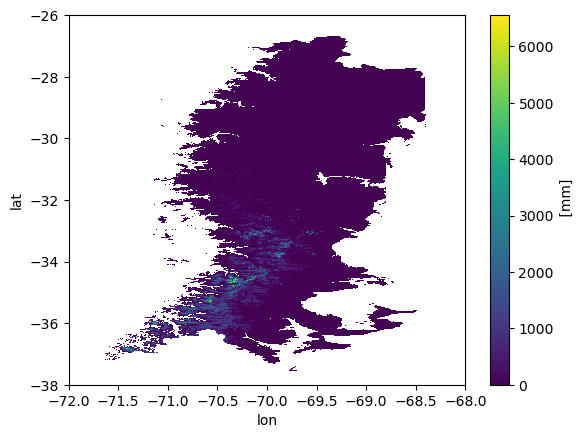

In [4]:
swe_april.plot()

In [5]:
# Bounding box [west, south, east, north]
bbox = [
    float(swe_april.lon.min()),
    float(swe_april.lat.min()),
    float(swe_april.lon.max()),
    float(swe_april.lat.max())
]
print(f"Bounding box (W, S, E, N): {bbox}")

Bounding box (W, S, E, N): [-72.0, -38.0, -68.0, -26.0]


In [6]:
import os
import glob

# Get all available ANDES SWE files
data_dir = '../data/andes_reanalysis'
files = sorted(glob.glob(f'{data_dir}/ANDES_SWE_WY*.h5'))
print(f"Found {len(files)} files")

# Build list of April 1st slices for each water year
april1_slices = []

for filepath in files:
    # Extract water year
    wy = int(filepath.split('WY')[-1].split('.')[0])
    april1_date = f'{wy}-04-01'
    
    print(f"Loading WY{wy} -> {april1_date}...")
    
    # Load just April 1st
    da = load_andes_swe_slice(filepath, april1_date)
    
    # Add time coordinate
    da = da.expand_dims(time=[pd.Timestamp(april1_date)])
    
    april1_slices.append(da)
    
    # Clean up
    del da

# Concatenate all years along time dimension
print("\nConcatenating all years...")
ds_april1 = xr.concat(april1_slices, dim='time')
ds_april1.name = 'SWE'
ds_april1.attrs['units'] = 'mm'
ds_april1.attrs['description'] = 'April 1st SWE from ANDES Reanalysis'

# Convert to Dataset
ds_april1 = ds_april1.to_dataset()

print(f"\nFinal shape: {dict(ds_april1.sizes)}")
print(f"Time range: {ds_april1.time.values[0]} to {ds_april1.time.values[-1]}")
print(f"Memory: {ds_april1.nbytes / 1e6:.1f} MB")

# Save to NetCDF
output_file = f'{data_dir}/andes_swe_april1_1993_2015.nc'
ds_april1.to_netcdf(output_file)
print(f"\nSaved: {output_file}")

ds_april1

Found 20 files
Loading WY1993 -> 1993-04-01...
Loading WY1994 -> 1994-04-01...
Loading WY1998 -> 1998-04-01...
Loading WY1999 -> 1999-04-01...
Loading WY2000 -> 2000-04-01...
Loading WY2001 -> 2001-04-01...
Loading WY2002 -> 2002-04-01...
Loading WY2003 -> 2003-04-01...
Loading WY2004 -> 2004-04-01...
Loading WY2005 -> 2005-04-01...
Loading WY2006 -> 2006-04-01...
Loading WY2007 -> 2007-04-01...
Loading WY2008 -> 2008-04-01...
Loading WY2009 -> 2009-04-01...
Loading WY2010 -> 2010-04-01...
Loading WY2011 -> 2011-04-01...
Loading WY2012 -> 2012-04-01...
Loading WY2013 -> 2013-04-01...
Loading WY2014 -> 2014-04-01...
Loading WY2015 -> 2015-04-01...

Concatenating all years...

Final shape: {'time': 20, 'lat': 12001, 'lon': 4001}
Time range: 1993-04-01T00:00:00.000000000 to 2015-04-01T00:00:00.000000000
Memory: 7682.7 MB

Saved: ../data/andes_reanalysis/andes_swe_april1_1993_2015.nc


<xarray.Dataset> Size: 8GB
Dimensions:  (time: 20, lat: 12001, lon: 4001)
Coordinates:
  * time     (time) datetime64[ns] 160B 1993-04-01 1994-04-01 ... 2015-04-01
  * lat      (lat) float64 96kB -26.0 -26.0 -26.0 -26.0 ... -38.0 -38.0 -38.0
  * lon      (lon) float64 32kB -72.0 -72.0 -72.0 -72.0 ... -68.0 -68.0 -68.0
Data variables:
    SWE      (time, lat, lon) float64 8GB nan nan nan nan ... nan nan nan nan